# Demersal & Reef Fishing-Zone Prediction (LightGBM)

This notebook trains, evaluates, and visualizes the **LightGBM Gradient Boosted Trees Model** for predicting reef and demersal fishing zones across the Philippine EEZ.

### Predictor Features:
- **Bathymetry (`bathymetry`)**: Seafloor elevation (m) from GEBCO 2023.
- **Slope (`slope`)**: Seafloor gradient (degrees) from GEBCO.
- **Rugosity (`rugosity`)**: Vector Ruggedness Measure from GEBCO.
- **Distance to Reef (`distance_to_reef`)**: Distance (km) to nearest coral reef derived from Allen Coral Atlas.
- **Benthic Habitat (`benthic_habitat`)**: Categorical substrate type (`Shallow_Coral_Reef`, `Reef_Slope_Lagoon`, `Shelf_Hard_Bottom`, `Deep_Benthic_Sediment`).
- **Bottom Temperature (`bottom_temperature`)**: Seafloor potential temperature (°C) from Copernicus Marine.
- **Bottom Current Speed (`bottom_current_speed`)**: Seafloor horizontal velocity magnitude (m/s) from Copernicus Marine.
- **Tidal Amplitude (`tidal_amplitude`)**: Sea surface height range / tidal dynamics (m) from ocean physics.

In [1]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


--- 
## 1 · Load Preprocessed Demersal Dataset
We load `demersal_lightgbm_ready.csv`, which combines occurrence records (GBIF demersal/reef families) and pseudo-absences with 8 spatio-temporal features.

In [2]:
data_file = 'demersal_lightgbm_ready.csv'
df = pd.read_csv(data_file)
print(f"Loaded dataset: {df.shape[0]} rows × {df.shape[1]} columns\n")

print("Class Balance:")
print(df['presence'].value_counts().rename({1: 'Presence (1)', 0: 'Pseudo-Absence (0)'}))

print("\nSample Data:")
df[['family', 'decimalLatitude', 'decimalLongitude', 'presence', 'bathymetry', 'distance_to_reef', 'bottom_temperature', 'benthic_habitat']].head(10)

Loaded dataset: 16680 rows × 15 columns

Class Balance:
presence
Pseudo-Absence (0)    12510
Presence (1)           4170
Name: count, dtype: int64

Sample Data:


,family,decimalLatitude,decimalLongitude,presence,bathymetry,distance_to_reef,bottom_temperature,benthic_habitat
0,Serranidae,13.734902,120.880361,1,-294.0,0.897784,29.270777,Deep_Benthic_Sediment
1,Serranidae,13.760373,120.912701,1,-150.0,0.285991,29.270777,Shelf_Hard_Bottom
2,Serranidae,13.764108,120.906658,1,-258.0,0.817259,29.270777,Deep_Benthic_Sediment
3,Serranidae,13.754917,120.906262,1,0.0,0.413854,29.270777,Shallow_Coral_Reef
4,Serranidae,13.715397,120.871400,1,-120.0,0.315024,29.270777,Shelf_Hard_Bottom
5,Serranidae,9.041406,123.008427,1,0.0,0.050476,29.308254,Shallow_Coral_Reef
6,Serranidae,13.689805,120.889725,1,-934.0,0.173319,29.270777,Deep_Benthic_Sediment
7,Serranidae,13.757000,120.919187,1,-52.0,0.421059,29.270777,Reef_Slope_Lagoon
8,Serranidae,13.715397,120.871400,1,-120.0,0.315024,29.270777,Shelf_Hard_Bottom
9,Serranidae,9.723009,124.548737,1,-73.0,0.132143,29.270777,Reef_Slope_Lagoon


---
## 2 · Feature Matrix & Stratified Train/Validation Split
We cast categorical features and perform an 80/20 train/test split.

In [3]:
feature_cols = [
    "bathymetry", 
    "slope", 
    "rugosity", 
    "distance_to_reef", 
    "bottom_temperature", 
    "bottom_current_speed", 
    "tidal_amplitude",
    "benthic_habitat"
]
target_col = "presence"

# Ensure categorical type for LightGBM
df['benthic_habitat'] = df['benthic_habitat'].astype('category')

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train samples: {len(X_train)} (Presence: {y_train.sum()}, Absence: {(y_train==0).sum()})")
print(f"Test samples:  {len(X_test)}  (Presence: {y_test.sum()}, Absence: {(y_test==0).sum()})")

Train samples: 13344 (Presence: 3336, Absence: 10008)
Test samples:  3336  (Presence: 834, Absence: 2502)


---
## 3 · LightGBM Model Training
We train gradient-boosted trees with categorical support for `benthic_habitat` and early stopping.

In [4]:
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=['benthic_habitat'])
lgb_eval  = lgb.Dataset(X_test, label=y_test, reference=lgb_train, categorical_feature=['benthic_habitat'])

params = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 6,
    "feature_fraction": 0.85,
    "bagging_fraction": 0.80,
    "bagging_freq": 1,
    "min_child_samples": 20,
    "verbose": -1,
    "random_state": 42
}

evals_result = {}
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_eval],
    valid_names=["train", "eval"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

# Save trained model
model.save_model('parola_demersal_model.txt')
print("\n💾 Saved trained model artifact to parola_demersal_model.txt")

[100]	train's auc: 0.985514	train's average_precision: 0.958844	eval's auc: 0.980345	eval's average_precision: 0.939438
[200]	train's auc: 0.9915	train's average_precision: 0.975027	eval's auc: 0.984374	eval's average_precision: 0.952808
[300]	train's auc: 0.994368	train's average_precision: 0.98317	eval's auc: 0.986001	eval's average_precision: 0.958262
[400]	train's auc: 0.995803	train's average_precision: 0.987342	eval's auc: 0.987036	eval's average_precision: 0.961682
[500]	train's auc: 0.996603	train's average_precision: 0.989693	eval's auc: 0.987423	eval's average_precision: 0.962939

💾 Saved trained model artifact to parola_demersal_model.txt


---
## 4 · Model Evaluation & Diagnostic Plots
We evaluate ROC-AUC, Average Precision (PR-AUC), and display diagnostic performance charts.

🎯 Validation ROC-AUC Score:          0.9876
🎯 Validation Average Precision (AP): 0.9637

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2502
           1       0.89      0.92      0.91       834

    accuracy                           0.95      3336
   macro avg       0.93      0.94      0.94      3336
weighted avg       0.95      0.95      0.95      3336



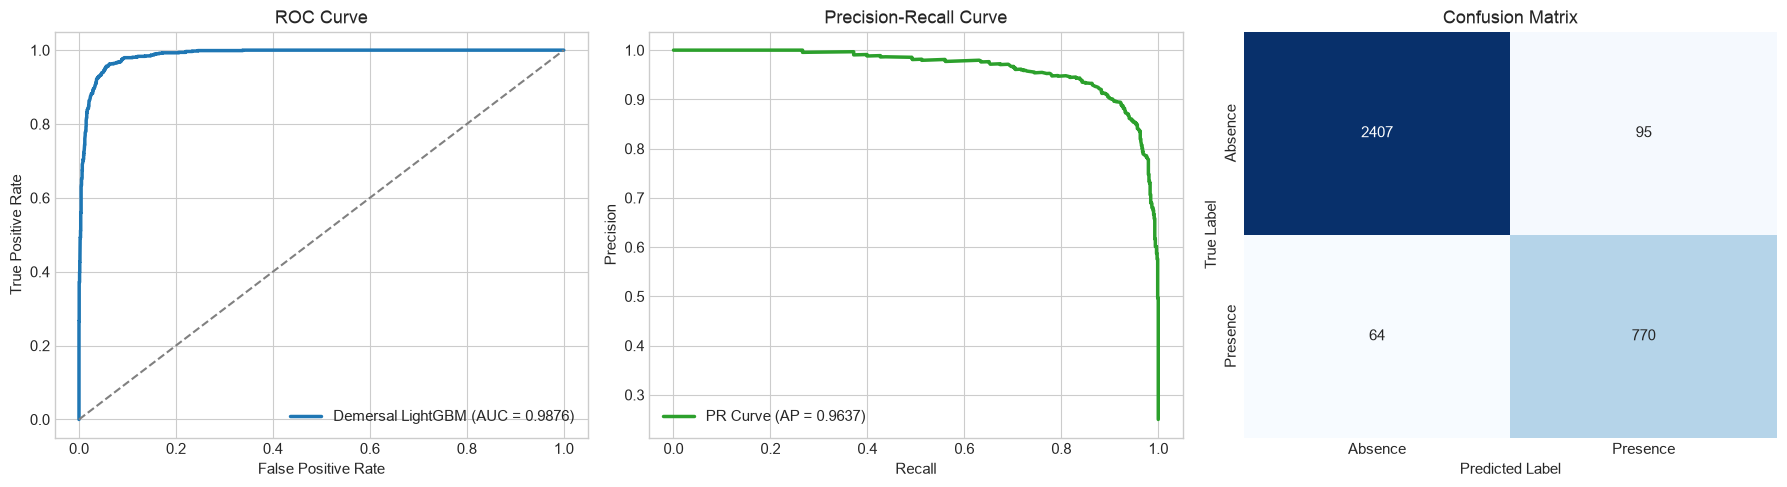

In [5]:
y_pred_prob = model.predict(X_test)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_pred_prob)
test_ap  = average_precision_score(y_test, y_pred_prob)

print("=" * 55)
print(f"🎯 Validation ROC-AUC Score:          {test_auc:.4f}")
print(f"🎯 Validation Average Precision (AP): {test_ap:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# Create 3-panel figure: ROC curve, PR curve, and Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Demersal LightGBM (AUC = {test_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# 2. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[1].plot(rec, prec, color='#2ca02c', lw=2.5, label=f'PR Curve (AP = {test_ap:.4f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], cbar=False,
            xticklabels=['Absence', 'Presence'], yticklabels=['Absence', 'Presence'])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

---
## 5 · Feature Importance Analysis
We compute and plot feature importances based on Information Gain.

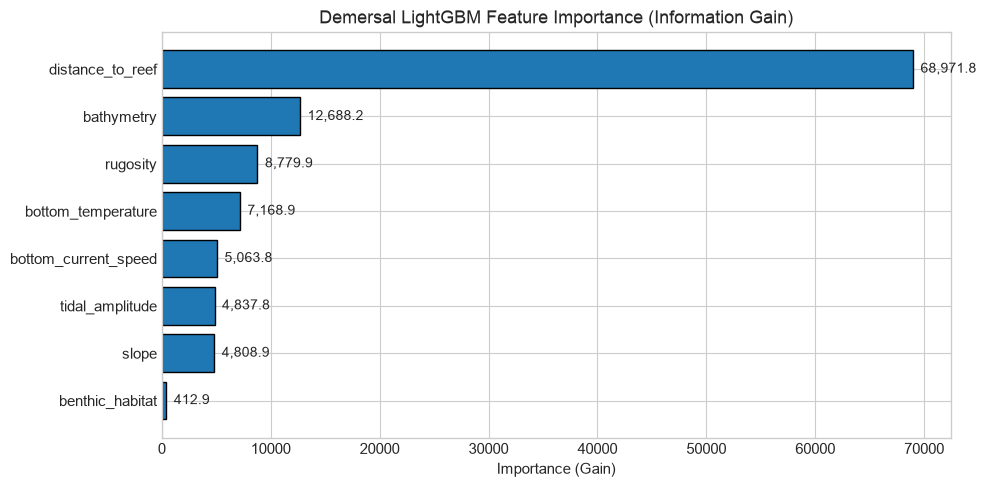

In [6]:
importance = model.feature_importance(importance_type='gain')
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Gain': importance
}).sort_values(by='Importance_Gain', ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance_Gain'], color='#1f77b4', edgecolor='black')
plt.title('Demersal LightGBM Feature Importance (Information Gain)')
plt.xlabel('Importance (Gain)')

for bar in bars:
    width = bar.get_width()
    plt.text(width + max(feat_imp['Importance_Gain'])*0.01, bar.get_y() + bar.get_height()/2,
             f"{width:,.1f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 6 · Spatial Demersal Fishing Zone Prediction Map
Visualizing predicted demersal fishing zone suitability probabilities across the Philippine EEZ.

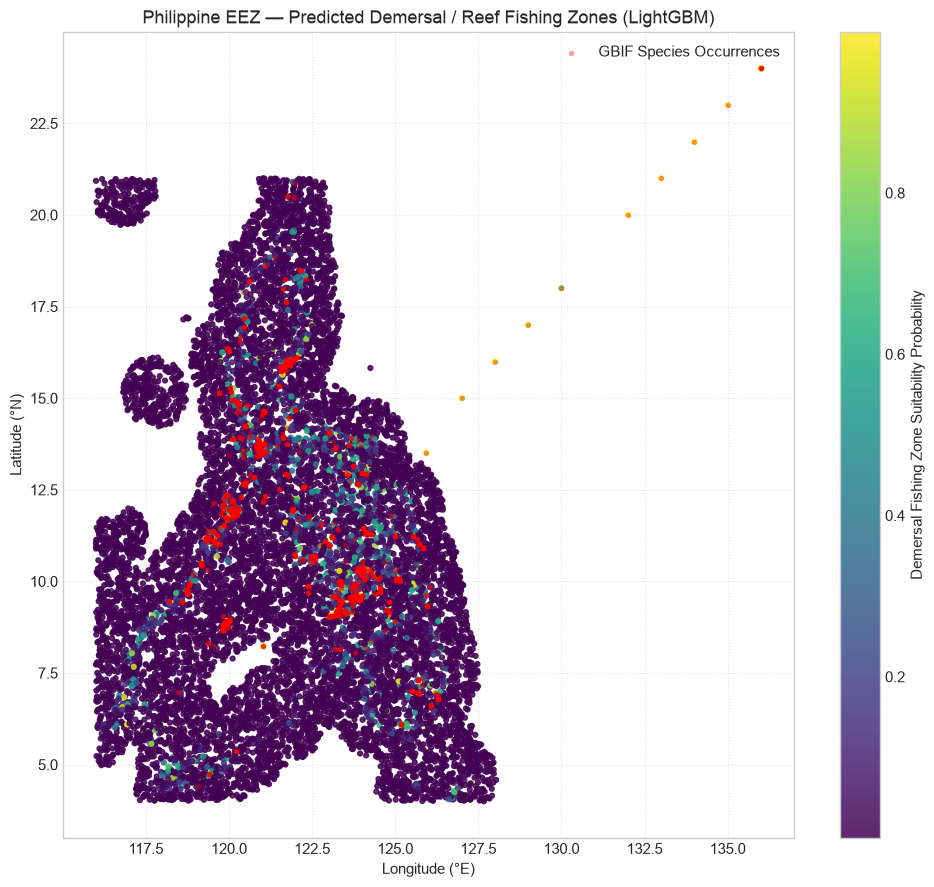

In [7]:
df['pred_prob'] = model.predict(X)

plt.figure(figsize=(10, 9))
sc = plt.scatter(
    df['decimalLongitude'], 
    df['decimalLatitude'], 
    c=df['pred_prob'], 
    cmap='viridis', 
    s=12, 
    alpha=0.85
)
cbar = plt.colorbar(sc)
cbar.set_label('Demersal Fishing Zone Suitability Probability')

# Highlight presence observations
pres_df = df[df['presence'] == 1]
plt.scatter(pres_df['decimalLongitude'], pres_df['decimalLatitude'], s=8, color='red', alpha=0.3, label='GBIF Species Occurrences')

plt.title('Philippine EEZ — Predicted Demersal / Reef Fishing Zones (LightGBM)')
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()